# Welcome to World Happiness Data Engineering Project

##### Requirement:
1. Load data into dataframes 
2. Transform data in the dataframes 
3. Load data from dataframes into delta tables 
4. Apply data tranformations using Dataflow Gen2
5. Orchestrate the ETL process using Data Pipeline
6. Develop Medallion Architecture


In [17]:
#Create dataframe for year 2022
df_2022 = spark.read.format("csv").option("header","true").option("inferSchema", "true").load("Files/Data/2022.csv")
# df now is a Spark DataFrame containing CSV data from "Files/Data/2022.csv".
display(df_2022)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 19, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, cc889d01-3198-42bc-9b3f-0db614066769)

In [18]:
#Get number of records in a dataframe
df_2022.count()

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 20, Finished, Available, Finished, False)

147

In [19]:
#Get column names in the dataframe
df_2022.columns

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 21, Finished, Available, Finished, False)

['Country',
 'Happiness score',
 'Whisker-high',
 'Whisker-low',
 'Dystopia (1.83) + residual',
 'Explained by: GDP per capita',
 'Explained by: Social support',
 'Explained by: Healthy life expectancy',
 'Explained by: Freedom to make life choices',
 'Explained by: Generosity',
 'Explained by: Perceptions of corruption']

#### Transformations
1. Had to rename Happiness score to Ladder score as the name changed after the 2022 data was produced
2. Changed Whisker-high to Upper_Whisker
3. Changed Whisker-low to Lower_Whisker
4. Changed Dystopia (1.83) + residual to Dystopia_Residual

In [20]:
#Rename column headers in a dataframe
df_2022 = (df_2022
.withColumnRenamed("Country","Country")
.withColumnRenamed("Happiness score","Ladder_Score")
.withColumnRenamed("Whisker-high","Upper_Whisker")
.withColumnRenamed("Whisker-low","Lower_Whisker")
.withColumnRenamed("Dystopia (1.83) + residual","Dystopia_Residual")
.withColumnRenamed("Explained by: GDP per capita","Explained_by_GDP_Per_Capita")
.withColumnRenamed("Explained by: Social support","Explained_by_Social_Support")
.withColumnRenamed("Explained by: Healthy life expectancy","Explained_by_Healthy_Life_Expectancy")
.withColumnRenamed("Explained by: Freedom to make life choices","Explained_by_Freedom_To_Make_Life_Choices")
.withColumnRenamed("Explained by: Generosity","Explained_by_Generosity")
.withColumnRenamed("Explained by: Perceptions of corruption","Explained_by_Perceptions_Of_Corruption")
)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 22, Finished, Available, Finished, False)

In [21]:
#Find values end with * in the Country column and replace it with blanks
from pyspark.sql.functions import regexp_replace, col

df_2022 = df_2022.withColumn(
    "Country",
    regexp_replace(col("Country"), r"\*", "")
)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 23, Finished, Available, Finished, False)

In [22]:
#Add a new column which tells us when we received the data
from pyspark.sql.functions import lit, to_date

df_2022 = df_2022.withColumn(
    "DatePublished",
    to_date(lit("2022-03-20"))
)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 24, Finished, Available, Finished, False)

In [23]:
#Check the data structure of the dataframe
df_2022.printSchema()

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 25, Finished, Available, Finished, False)

root
 |-- Country: string (nullable = true)
 |-- Ladder_Score: double (nullable = true)
 |-- Upper_Whisker: double (nullable = true)
 |-- Lower_Whisker: double (nullable = true)
 |-- Dystopia_Residual: double (nullable = true)
 |-- Explained_by_GDP_Per_Capita: double (nullable = true)
 |-- Explained_by_Social_Support: double (nullable = true)
 |-- Explained_by_Healthy_Life_Expectancy: double (nullable = true)
 |-- Explained_by_Freedom_To_Make_Life_Choices: double (nullable = true)
 |-- Explained_by_Generosity: double (nullable = true)
 |-- Explained_by_Perceptions_Of_Corruption: double (nullable = true)
 |-- DatePublished: date (nullable = true)



In [24]:
#View the transformed data frame
display(df_2022)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 26, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2a8c25d7-6fb3-436b-b7cb-9e2bd01a3953)

In [25]:
#Save data into delta tables
df_2022.write.mode("overwrite").format("delta").saveAsTable("WorldHappiness_2022")

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 27, Finished, Available, Finished, False)

In [10]:
%%sql
--Retrieve data from the saved delta table
SELECT COUNT(*) FROM WorldHappiness_Lakehouse.dbo.worldhappiness_2022

StatementMeta(, ebd84491-53d3-47f6-ba19-211b9efef923, 12, Finished, Available, Finished, False)

<Spark SQL result set with 1 rows and 1 fields>

In [8]:
#Create dataframe for year 2023
df_2023 = spark.read.format("csv").option("header","true").option("inferSchema", "true").load("Files/Data/2023.csv")
# df now is a Spark DataFrame containing CSV data from "Files/Data/2023.csv".
display(df_2023)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 10, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d9252f5f-4e7c-4408-b838-157fe3efb2ce)

In [9]:
#Get number of records in a dataframe
df_2023.count()

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 11, Finished, Available, Finished, False)

137

In [10]:
#Get column names in the dataframe
df_2023.columns

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 12, Finished, Available, Finished, False)

['Country name',
 'Ladder score',
 'Standard error of ladder score',
 'upperwhisker',
 'lowerwhisker',
 'Logged GDP per capita',
 'Social support',
 'Healthy life expectancy',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption',
 'Ladder score in Dystopia',
 'Explained by: Log GDP per capita',
 'Explained by: Social support',
 'Explained by: Healthy life expectancy',
 'Explained by: Freedom to make life choices',
 'Explained by: Generosity',
 'Explained by: Perceptions of corruption',
 'Dystopia + residual']

In [11]:
#Rename column headers in a dataframe
df_2023 = (df_2023
.withColumnRenamed("Country name","Country")
.withColumnRenamed("Ladder score","Ladder_Score")
.withColumnRenamed("Standard error of ladder score","Standard_Error_of_Ladder_Score")
.withColumnRenamed("upperwhisker","Upper_Whisker")
.withColumnRenamed("lowerwhisker","Lower_Whisker")
.withColumnRenamed("Logged GDP per capita","Logged_GDP_Per_Capita")
.withColumnRenamed("Social support","Social_Support")
.withColumnRenamed("Healthy life expectancy","Healthy_Life_Expectancy")
.withColumnRenamed("Freedom to make life choices","Freedom_To_Make_Life_Choices")
.withColumnRenamed("Generosity","Generosity")
.withColumnRenamed("Perceptions of corruption","Perceptions_Of_Corruption")
.withColumnRenamed("Ladder score in Dystopia","Ladder_Score_in_Dystopia")
.withColumnRenamed("Explained by: Log GDP per capita","Explained_by_Log_GP_Per_Capita")
.withColumnRenamed("Explained by: Social support","Explained_by_Social_Support")
.withColumnRenamed("Explained by: Healthy life expectancy","Explained_by_Healthy_Life_Expectancy")
.withColumnRenamed("Explained by: Freedom to make life choices","Explained_by_Freedom_To_Make_Life_Choices")
.withColumnRenamed("Explained by: Generosity","Explained_by_Generosity")
.withColumnRenamed("Explained by: Perceptions of corruption","Explained_by_Perceptions_of_Corruption")
.withColumnRenamed("Dystopia + residual","Dystopia_Residual")
)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 13, Finished, Available, Finished, False)

In [12]:
#View the transformed data frame
display(df_2023)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 14, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 80a8a1fb-45d1-478a-9572-b430440f677a)

In [13]:
#Add a new column which tells us when we received the data
from pyspark.sql.functions import lit, to_date

df_2023 = df_2023.withColumn(
    "DatePublished",
    to_date(lit("2023-03-20"))
)

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 15, Finished, Available, Finished, False)

In [15]:
#Save data into delta tables
df_2023.write.mode("overwrite").format("delta").saveAsTable("WorldHappiness_2023")

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 17, Finished, Available, Finished, False)

In [16]:
%%sql
--Retrieve data from the saved delta table
SELECT COUNT(*) FROM WorldHappiness_Lakehouse.dbo.worldhappiness_2023

StatementMeta(, e55e4f74-e5fb-4288-b267-ed688a2a8307, 18, Finished, Available, Finished, False)

<Spark SQL result set with 1 rows and 1 fields>

#### Dataflow Gen2

I created a Dataflow Gen2, where the sources for 2022 and 2023, I downloaded the files from https://www.worldhappiness.report/data-sharing/ and the source for 2024, i added a Web API source to connect to the URL I shared.

I did some transformations and appended all the sources into 1 table called bronze_WorldHappiness


StatementMeta(, 3f9ef017-016d-4b50-8b59-06b05dc89600, 27, Finished, Available, Finished, False)

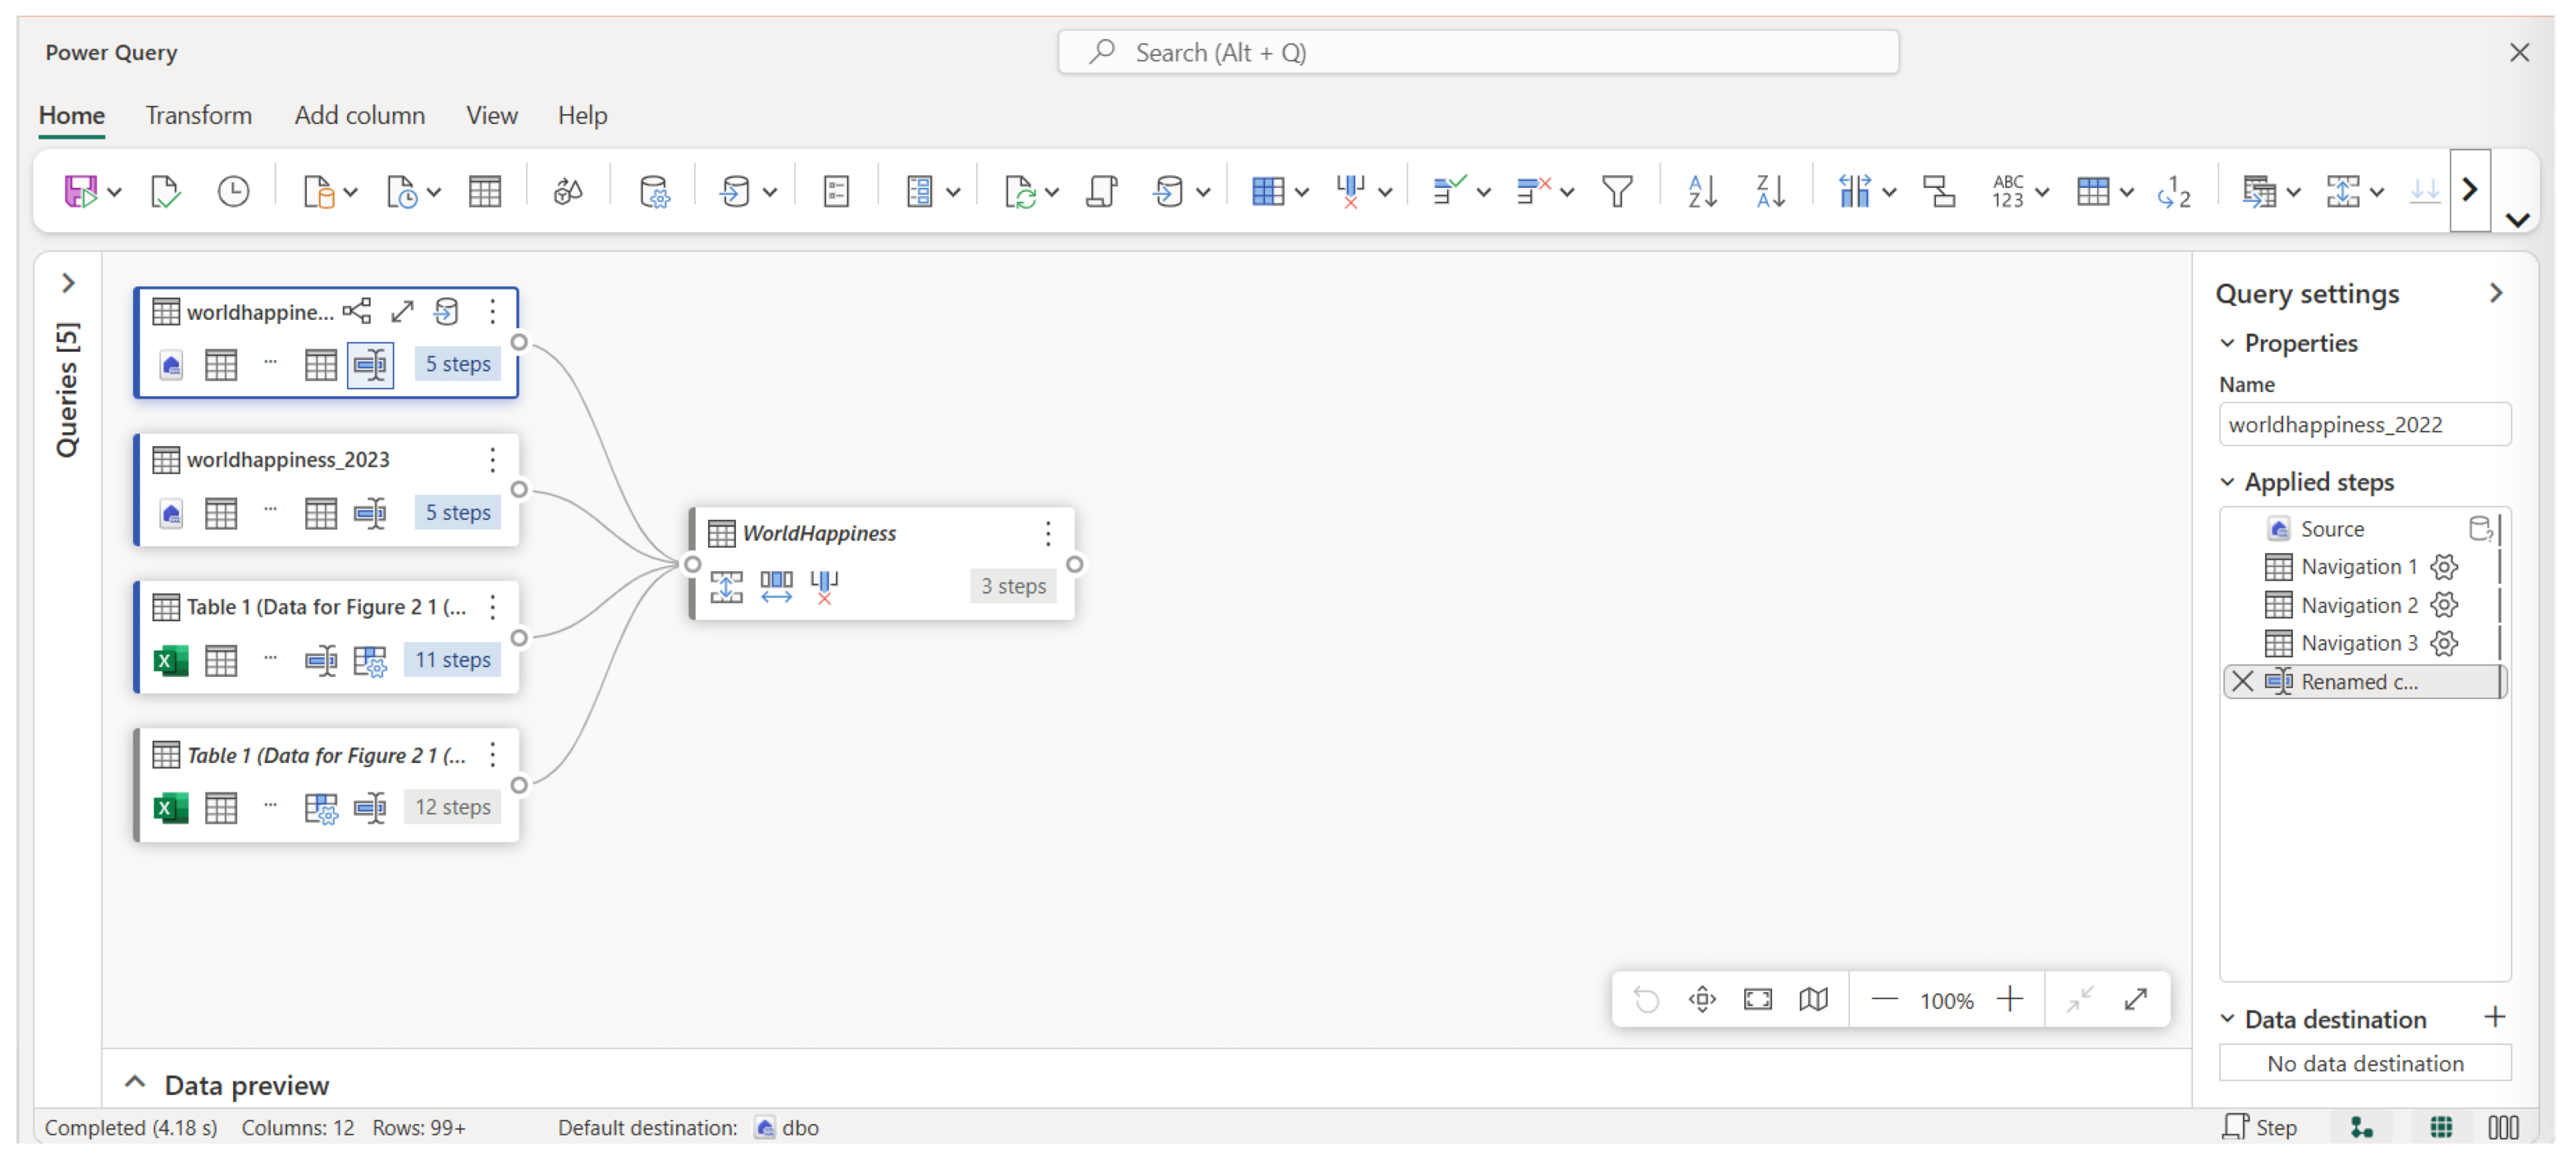

In [6]:
# Mount external lakehouse  "WorldHappiness_Lakehouse" into specified local path.
# Note: NotebookUtils is only supported on runtime v1.2 and above. If you are using runtime v1.1, please use mssparkutils instead.
##notebookutils.fs.mount("abfss://a7290ea3-e20c-4a18-8ef3-ded93345be99@onelake.dfs.fabric.microsoft.com/cbc1b103-af6b-4d07-8174-a632aedd521e", "/lakehouse/WorldHappiness_Lakehouse")

##import matplotlib.pyplot as plt
######import matplotlib.image as mpimg
# Load image
##image = mpimg.imread(notebookutils.fs.getMountPath('/lakehouse/WorldHappiness_Lakehouse/Files/Dataflow Diagram1.png'))
# Plot image in the output
##plt.figure(figsize=(20, 12), dpi=200)
##image_plot = plt.imshow(image)
##plt.axis('off')
##plt.show()

#### Pipeline

This is a data pipeline where it takes the current notebook and the dataflow Gen2 which I have created and it orchestrates the ETL process

StatementMeta(, adcce9cd-9a2f-4223-ad96-d463f386785b, 16, Finished, Available, Finished, False)

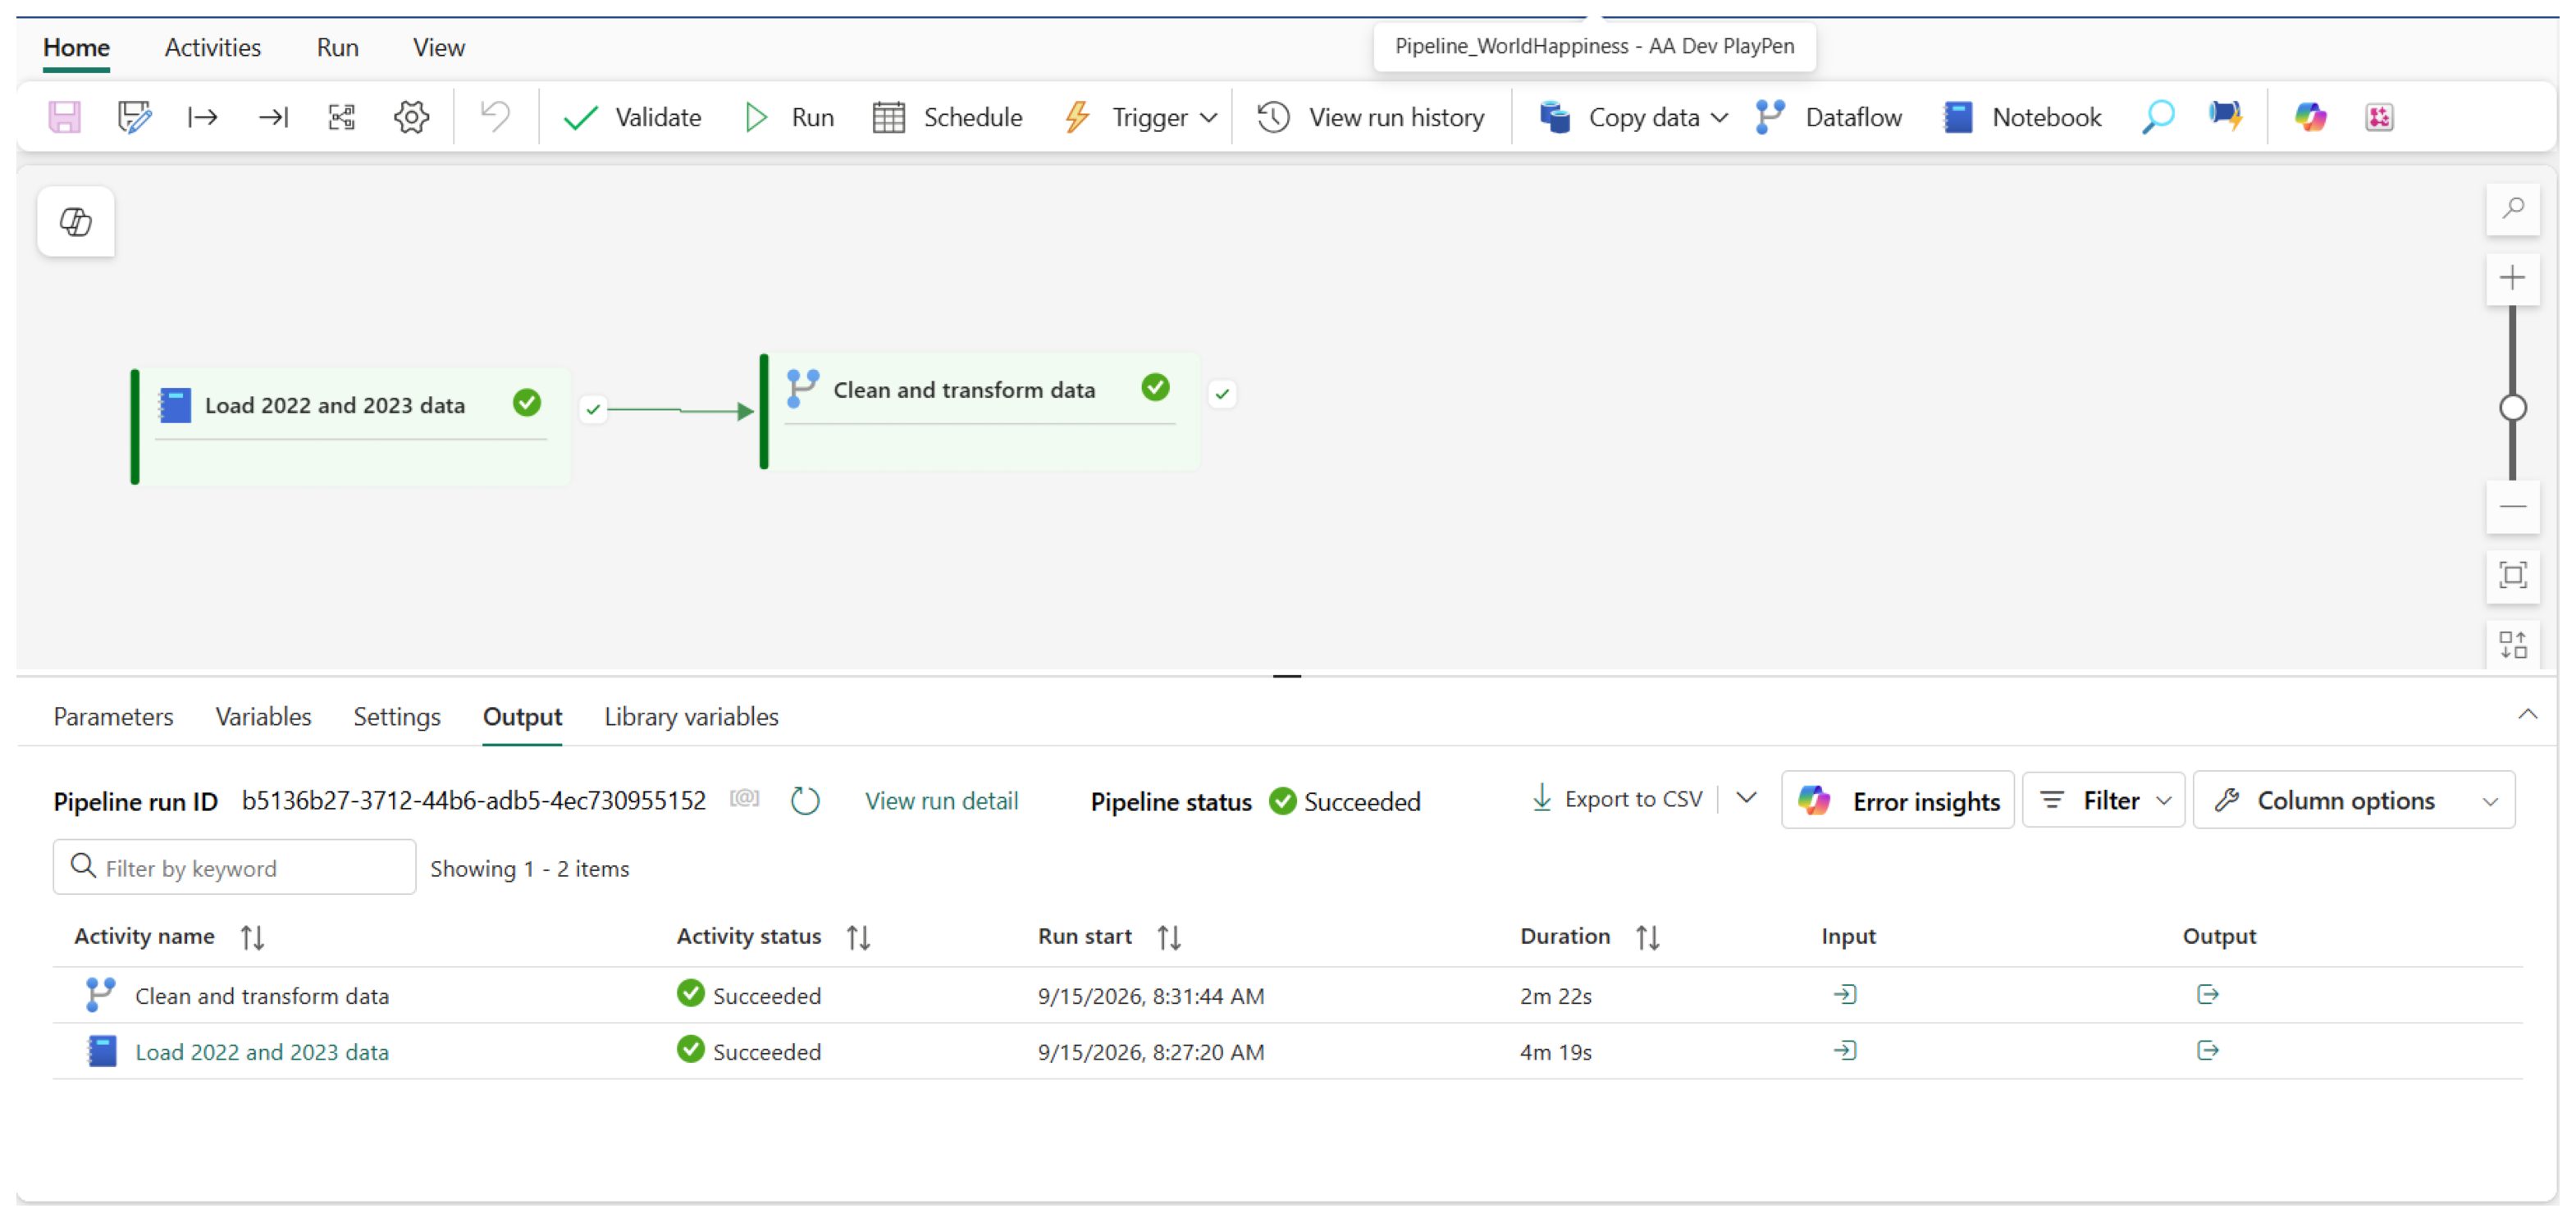

In [4]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image1 = mpimg.imread("/lakehouse/default/Files/Pipeline.png")
# Plot image in the output
plt.figure(figsize=(20, 12), dpi=200)
image_plot1 = plt.imshow(image1)
plt.axis('off')
plt.show()
